---

# **Milestone 5:** Final Model

### Project Group #2: <i> Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch</i>

---


[Instructions](https://edstem.org/us/courses/74185/lessons/130679/slides/736238)

<div style='background:#FBB360; color: black; padding: 5px'>

<h3><b>TODOs</b> (<i>Delete Later</i>)</h3>

**Elaine's Comments**

- Very promising.  Wondering why the choice for splits were  76.5, 13.5, 10.

- I agree that downsampling is not ideal. But this is inherent in your data. Not much you can do about it other than launch more rockets yourselves.

- Typo in "'Figure 4.3: Proportion of Objects that Meet State Cound Threshold'"

- Are you pulling this final model from somewhere or is this your own Frankenstein? 

- As something to think about down the line, I wonder if you would be able to predict time of decay from this data instead of a classification prediction. 

**Deadlines**

- [5/7] last day we can schedule a dry run with Elaine

- [5/9] Final project submission is due: May 9th, 2025 at 9:59pm.

**Components due on 5/9**

- Peer evaluations

- video presentation 

- Code notebook

**Content Notes**

- [x] Group Canvas number + group member names 

- [] TOC (table of contents) 

- [] Intro: Motivation, context, and framing of the problem


-  Code specifics 

    - [] Describe what libraries your codes depend on.

    - [] If your codes require specific environment configurations, make sure to explain them.


- [] Description of the data, how data was handled

- [] EDA specific to report's content, mainly MS3

- [] Modeling approach, logical description of modeling decisions and process

    - Include an illustration/flow chart of your model. This can also be used for your presentation.

- [] Results: drawing reasonable conclusions & speculations, addressing strengths, limitations, and future works

- [] Cite every outside source

**Form Notes**

- Make sure a label and an explanation follows every visualization (ex. "Figure 1.2 The above figure displays...")

- The notebook should read like a report to an employer with appropriate comments and explanations.

- Overall communication and clarity: good visuals, minimal typos, readability

- Coding efficiency and style

- Depth and thoroughness

- You can move additional code to an appendix notebook if it helps make the main report notebook more concise.

</div>








#### Table of Contents 

1.  [Introduction](#1-intro)

2.  [Code Specs](#2-code)

3.  [Data Description](#3-data)

4.  [EDA](#4-eda)

5.  [Modelng Approach](#5-model)

6.  [Results](#6-results)

    [References](#refs)


---
### 1. Introduction <a class="anchor" id="1-intro"></a>
---

**DIRECTIONS (DELETE LATER): Motivation, context, and framing of the problem**

### 1.1 Background <a class="anchor" id="1-1-background"></a>

Currently, there are around 30,000 publicly cataloged objects in Earth's orbit. In reality, the number is likely much higher, as 1) not every piece of debris in orbit has a known position or identification number,  2) not every payload is publicly disclosed by the government of origin, and  3) different organizations report varying figures.

Traditionally, space objects are classified into three categories:

1. **Payloads**: Functional spacecraft or satellites launched into space to perform specific missions, such as communication, navigation, or research.

2. **Rocket Bodies**: Parts of launch vehicles (e.g., stages) that delivered payloads to orbit but remain in space as non-operational objects.

3. **Debris**: Non-functional fragments or objects in space, including pieces from collisions, explosions, or decommissioned satellites, that no longer serve any purpose.

While all objects are subject to the same orbital perturbations, the nature of each object type should produce identifiable patterns in their orbital elements. For example, active payloads will conduct station-keeping maneuvers to maintain their desired orbits. Geostationary satellites, for instance, have orbital periods of nearly exactly 1,440 minutes—matching Earth's rotation. However, if they stop performing station-keeping maneuvers, their orbits will begin to drift due to various perturbative forces (gravity, drag, radiation pressure, solar activity, etc.). Likewise, although both are essentially space junk, debris and rocket bodies should also exhibit distinct orbital behaviors due to differences in their average size, mass, and origin.

### 1.2 Research Question <a class="anchor" id="1-2-research-question"></a>

**Given a history of orbital states, can we predict with confidence any given object's type?**

Initially, we aimed to use two years of orbital data, removing time-dependent elements and identifiers to train our model to perform type classification. However, we are now pivoting to leverage the time dimension, using not a stationary set of elements, but rather a time-separated element histories as input to our three-type classification model. This pivot allows us to utilize more complex modeleling classes and techniques. Note: when considering states independently we will still exclude the epoch from our features but will likely incorporate it when grouping states by ID to encode order in the history. 

Our EDA has confirmed that there are differences in orbital elements amongst object types, which are most pronounced in inclination, eccentritiy, apogee, and argument of perigee. Moreover, by examing the correlations between our features, we identified several meaningful patterns (and noted the ones which were trivial/meaningless). 

--- 
### 2. Code Specs <a class="anchor" id="2-code"></a>
---

**DIRECTIONS (DELETE LATER): Code specifics**

- **Describe what libraries your codes depend on.**

- **If your codes require specific environment configurations, make sure to explain them.**


Our project relies on the following libraries:

Data fetching:
- `configparser` : to load authentication for Space-Track API.
- `requests` : to query the Space-Track API.

Data processing:
- `datetime` : for datetime manipulations.
- `json` : to load data from and save to JSON format.
- `math` : for constants such as $\pi$.
- `zipfile` : to load data from and save to ZIP format.

Visualization:
- `matplotlib` : to create histograms, bar plots, and scatter plots.
- `seaborn` : to create heatmaps and kernel density plots.

Miscellaneous:
- `os` : to detect if weights exist.
- `pickle` : to save and load training history.
- `numpy` : for various array operations.
- `pandas` : to manipulate data.
- `sklearn` : for `StandardScaler` to scale numerical variables, `LabelEncoder` to encode labels from string to int, `train_test_split` to create train/validation/test splits, `confusion_matrix` and `ConfusionMatrixDisplay` to evaluate the model.
- `tensorflow` and `keras` : to build, compile, and train the neural network.

In [1]:
# IMPORTS
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# utilities
import utils.visualization as viz
from utils.processing import filter_rsos_by_min_state_count, rso_train_test_split, assemble_scaled_state_df

RANDOM_STATE=209
PADDING_VALUE=-999.0 # <-- -999.0 never appears in our data, safe to use as the padding token

2025-05-07 23:36:04.977179: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-07 23:36:04.977241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-07 23:36:04.978058: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-07 23:36:04.984535: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---
### 3. Data Description <a class="anchor" id="3-data"></a>
---

**DIRECTIONS (DELETE LATER): Description of the data, how data was handled**

#### 3.1 Data Fetching

**TODO: Describe how we downloaded from the Space-Track API**

#### 3.2 Data Processing

**TODO: Describe how we dropped analyst objects, identified other missing variables (type of missingness), and how we scaled the numerical variables.**

#### 3.3 Final Data

Our final dataframe consists of data from:

1. Historical State information - collected from spacetrack on the 1st and 15th of each moth ranging from 03/15/2023 to 03/15/2025.

2. Satellite catalog (satcat) information - descriptive information about a satellite.

3. Calculated additional values - semi-major axis, apogee, perigee, and orbital regime need to be calculated using state information.

The table below explains the response variable and predictors to be used in our modeling.

<table>
    <tr>
        <th>Feature</th> <th>Data Type</th> <th>Units</th> <th>Description</th>
    </tr>
    <tr>
        <td>TYPE (response)</td> <td>String/Enum</td> <td>-</td> <td>Type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td>INCL</td> <td>Float</td> <td>Degree</td> <td>Orbit inclination</td>
    </tr>
    <tr>
        <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>Right Ascension of the Ascending Node - longitude of the point where the spacecraft crosses the equatorial plane</td>
    </tr>
    <tr>
        <td>ECC</td> <td>Float</td> <td>[0,1]</td> <td>Eccentricity - measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>Argument of perigee - rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>Revolutions per day given orbit</td>
    </tr>
    <tr>
        <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>Semi-major axis - the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>Furthest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>Closest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day<sup>2</sup></td> <td>Ballistic coefficient measure (angular velocity)</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_2ND_DER</td> <td>Float</td> <td>Rev/Day<sup>3</sup></td> <td>2nd Derivative of Mean Motion (angular acceleration)</td>
    </tr>
    <tr>
        <td>B_STAR</td> <td>Float</td> <td>(radius of earth)<sup>-1</sup> </td> <td>Drag term or radiation pressure coefficient</td>
    </tr>
</table>

In [2]:
# Load the final dataframe
df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file

# Define predictors and response variable
X_cols = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 
          'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 
          'PERIGEE_KM', 'MEAN_MOTION_1ST_DER', 
          'MEAN_MOTION_2ND_DER', 'B_STAR']
y_col = 'TYPE'
print(f'The final model will have {len(X_cols)} predictors and predict {len(df_final["TYPE"].unique())} classes.')

# Display information about states and objects
print(f'\nThere are {df_final.shape[0]:,d} states with class distribution:')
print(df_final['TYPE'].value_counts())
df_objects = df_final.drop_duplicates(subset="NUMBER", keep="first")
print(f'\nThere are {df_objects.shape[0]:,d} unique objects with class distribution:')
print(df_objects['TYPE'].value_counts())

The final model will have 11 predictors and predict 3 classes.

There are 1,011,052 states with class distribution:
TYPE
PAYLOAD        548400
DEBRIS         371939
ROCKET BODY     90713
Name: count, dtype: int64

There are 30,495 unique objects with class distribution:
TYPE
PAYLOAD        15145
DEBRIS         12999
ROCKET BODY     2351
Name: count, dtype: int64


In [3]:
# Separate data into separate dataframes for each class
df_payload = df_final[df_final['TYPE'] == 'PAYLOAD']
df_rb = df_final[df_final['TYPE'] == 'ROCKET BODY']
df_debris = df_final[df_final['TYPE'] == 'DEBRIS'] 

In [4]:
# Scaled data used for PCA later in EDA section
response = 'TYPE'

# scale data for better performance with neural nets
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_final[X_cols]), columns=X_cols)
df_scaled.reset_index(drop=True, inplace=True)
df_response = df_final[[response]]
df_response.reset_index(drop=True, inplace=True)
df_scaled = pd.concat([df_response, df_scaled], axis=1)

# display the data
df_scaled.head(2)

,TYPE,INCL,RAAN,ECC,ARG_PER,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,MEAN_MOTION_2ND_DER,B_STAR
0,PAYLOAD,-1.196979,-1.313405,0.685616,1.243249,-0.153392,-0.274948,-0.208660,-0.323569,-0.032034,-0.007565,-0.109529
1,ROCKET BODY,-1.196343,0.862265,0.819142,-1.424497,-0.246231,-0.255350,-0.176047,-0.323377,-0.031479,-0.007565,-0.101960


---
### 4. EDA <a class="anchor" id="4-eda"></a>
---

**DIRECTIONS (DELETE LATER):EDA specific to report's content, mainly MS3**

#### 4.1 Principal Component Analysis (PCA)

In [5]:
# PCA without the specified columns below
df_to_use = df_scaled
df_to_use = df_to_use.drop(columns=['TYPE'])
pca = PCA(n_components=len(df_to_use.columns))  
pca_result = pca.fit_transform(df_to_use)

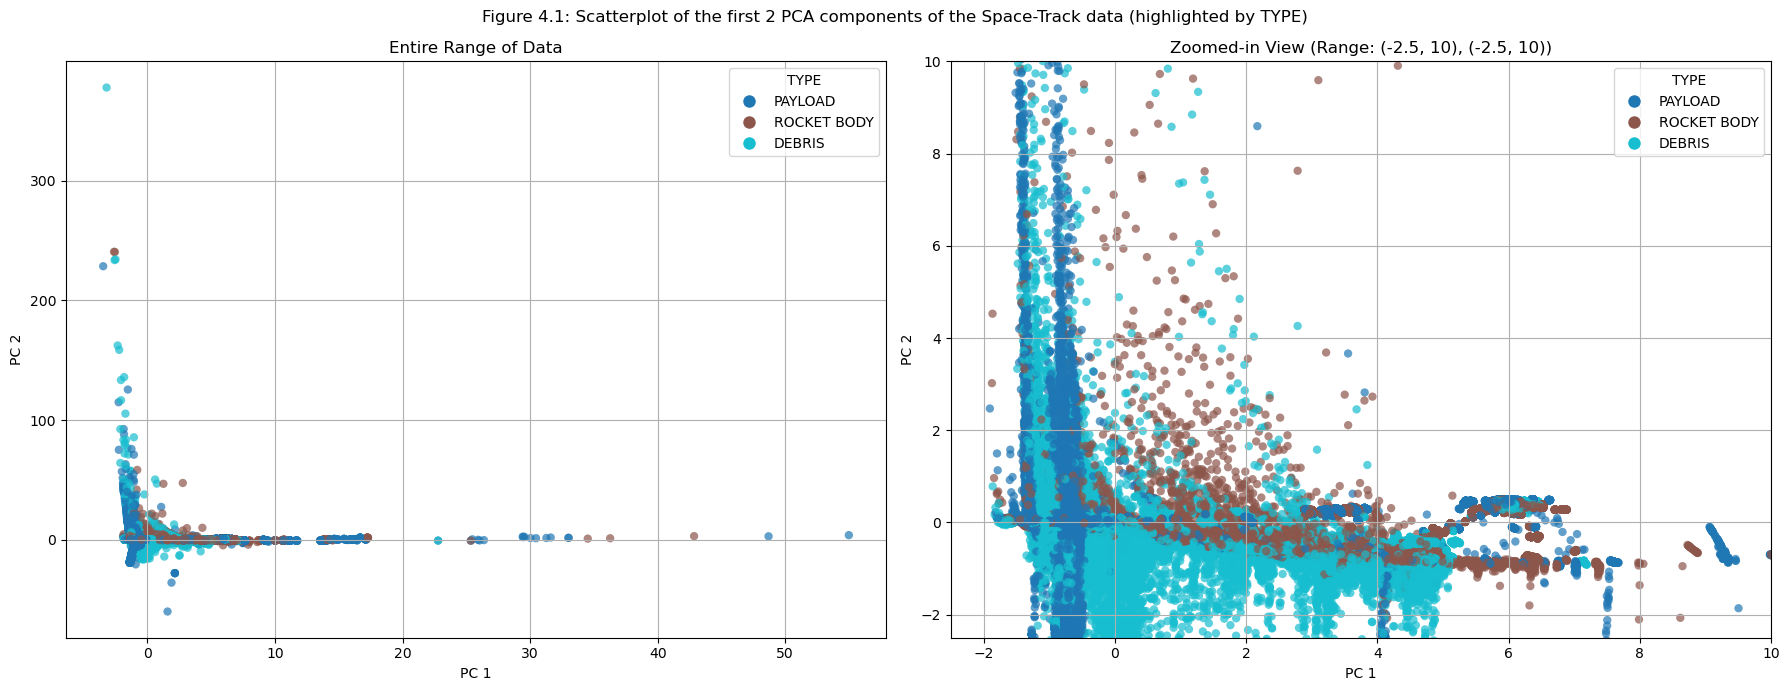

In [6]:
# visualize PCA results by type
viz.pca_pc1_pc2_pair(pca_result, df_scaled["TYPE"], "TYPE", "Figure 4.1: Scatterplot of the first 2 PCA components of the Space-Track data (highlighted by TYPE)", x_range=(-2.5, 10), y_range=(-2.5, 10))

Figure 4.1 presents our PCA plot colored by the response variable (TYPE). While the clusters are no longer as distinct as they were when we tried plotting by orbital regime, there are still complex patterns visible for certain types. These patterns may be too nuanced for a basic model to capture effectively, but our neural network (NN) should be capable of learning and modeling them.

#### 4.2 Correlation of Variables

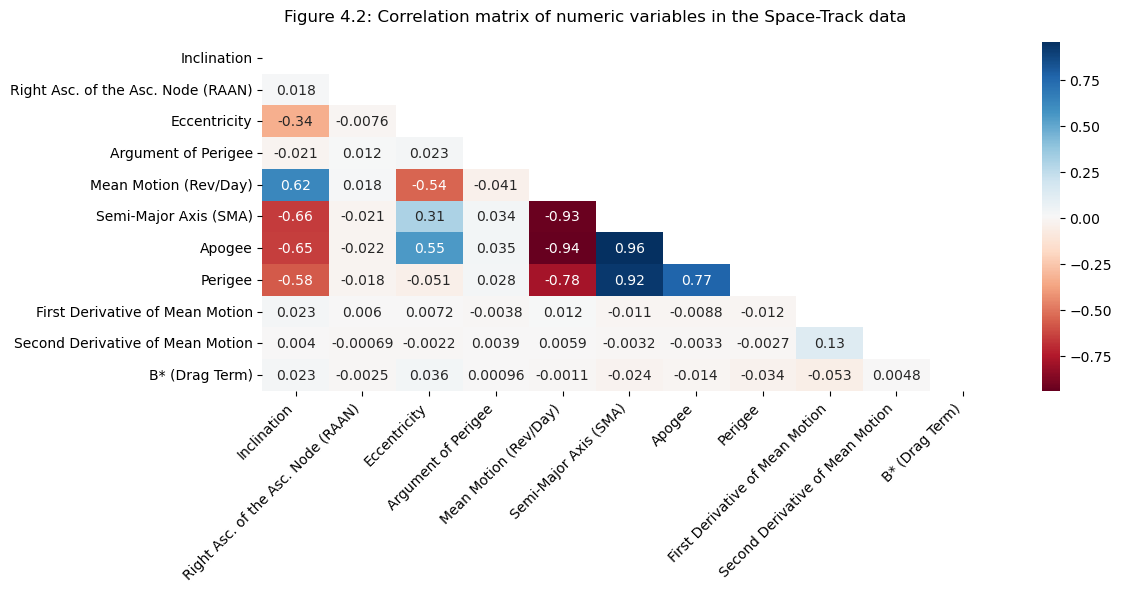

In [7]:
viz.plot_corr_matrix(df_final, X_cols, viz.pretty_column_names(), "Figure 4.2: Correlation matrix of numeric variables in the Space-Track data")

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>

#### 4.3 Distribution of Variables

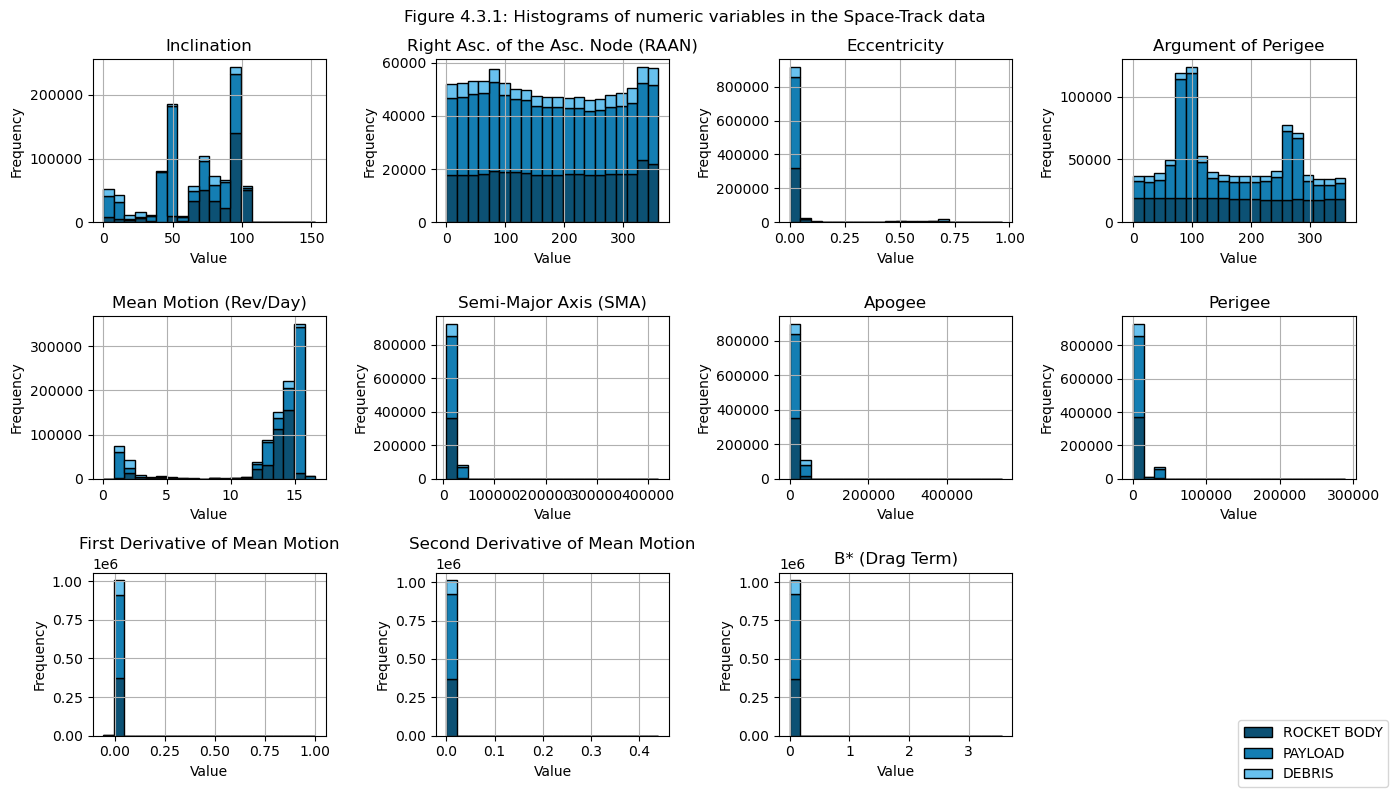

In [8]:
viz.plot_stacked_histograms([df_debris, df_payload,df_rb ], X_cols, viz.pretty_column_names(),"Figure 4.3.1: Histograms of numeric variables in the Space-Track data")

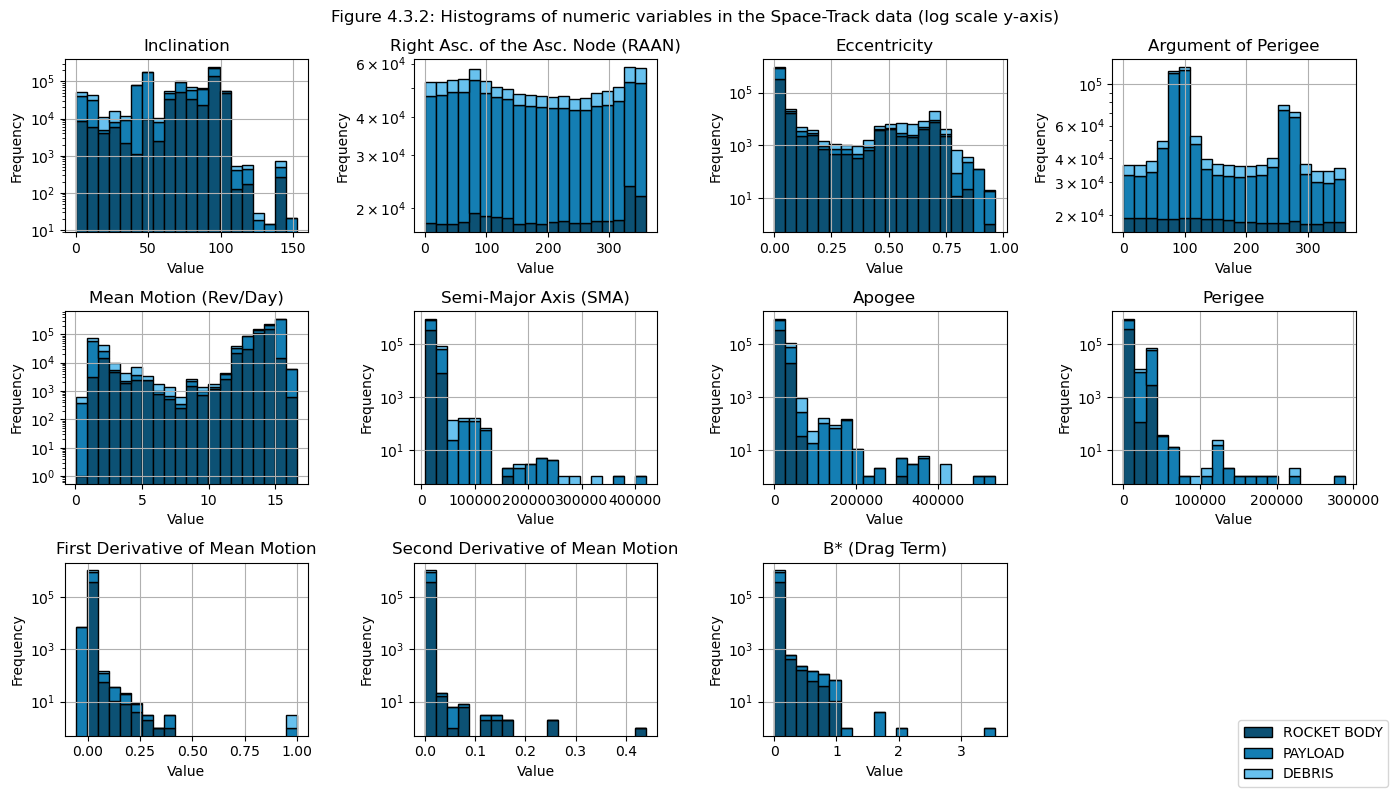

In [9]:
viz.plot_stacked_histograms_log_yaxis([df_debris, df_payload,df_rb ], X_cols, viz.pretty_column_names(),"Figure 4.3.2: Histograms of numeric variables in the Space-Track data (log scale y-axis)")

Figures 4.3.1 & 4.3.2: show the distribution of our numerical variables--separated by object type. 

We found that there is a severe class imbalance between the 3 types of space objects. They made up 54.24%, 36.78%, and 8.97% of our dataset for Payload, Debris, and Rocket Body respectively. To remedy this, we first applied one-hot encoding on the categorical variables, "RCS", "IS_CURRENT", "REGIME", and "COUNTRY", to convert them into numerical values. By using one-hot encoding, we avoid implying a natural order between categories that do not. Next, we applied Synthetic Minority Oversampling Technique (SMOTE) to generate synthetic samples for the minority classes. This balances the class distribution, which has the effect of improving the model's performance on the minority classes, and reduces bias towards the majority class. We will elaborate on how we used this SMOTE data in the Model section later.

#### 4.4 Number of States per Object

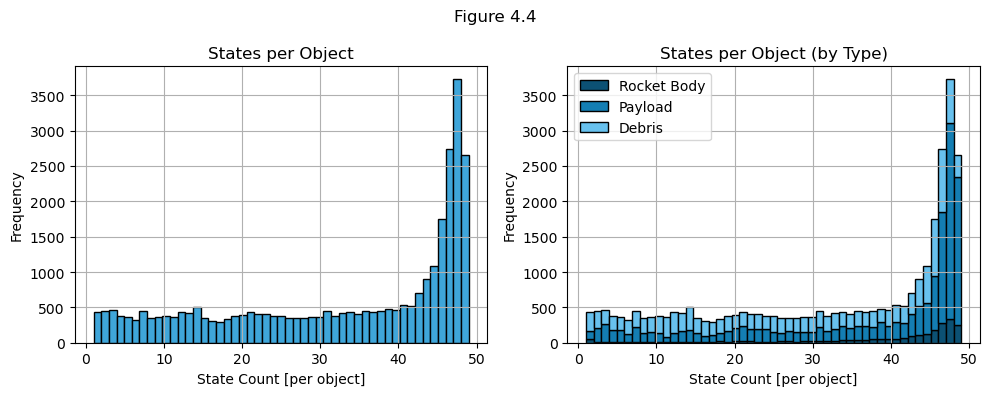

In [10]:
viz.plot_state_count_side_by_side("Figure 4.4", "States per Object","States per Object (by Type)", df_final, df_payload, df_rb, df_debris )

Figure 4.4 plots the number of states per object. We can observe that roughtly half of objects have around 40-50 states, with all three classes following a similar distribution.

---
### 5. Model <a class="anchor" id="5-model"></a>
---

**DIRECTIONS (DELETE LATER): Modeling approach, logical description of modeling decisions and process**

#### 5.1 Reshaping Data & Padding Objects

In [11]:
# Get maximum number of states for all objects
MAX_STATE_COUNT = df_final['NUMBER'].value_counts().max()
N_FEATURES = len(X_cols)

# Group by objects
grouped = df_final.groupby('NUMBER')

X_padded = []
y_labels = []

# Iterate through objects and pad
for number, group in grouped:

    # Pad states
    states = group[X_cols].values.astype(np.float32)
    padded = tf.keras.preprocessing.sequence.pad_sequences(
        [states], maxlen=MAX_STATE_COUNT, dtype='float32',
        padding='post', truncating='post', value=PADDING_VALUE
    )
    X_padded.append(padded[0])

    # Assign label
    label = group[response].iloc[0]
    y_labels.append(label)

X_array = np.array(X_padded).astype(np.float32)
y_array = np.array(y_labels)

print(f'X shape: {X_array.shape}')
print(f'y shape: {y_array.shape}')

X shape: (30495, 49, 11)
y shape: (30495,)


#### 5.2 Encoding Labels & Fitting Scaler

In [12]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_array).astype(np.int32)

# Fit the scaler
X_array_flat = X_array.reshape(-1, N_FEATURES)
valid_mask = ~(X_array_flat == PADDING_VALUE).all(axis=1)
X_array_flat_valid = X_array_flat[valid_mask]

scaler = StandardScaler()
scaler.fit(X_array_flat_valid)

StandardScaler()

#### 5.3 Train-Test Split

In [13]:
X_temp, X_test, y_temp, y_test = train_test_split(X_array, y_encoded, test_size=0.15, random_state=RANDOM_STATE, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=RANDOM_STATE, stratify=y_temp)

#### 5.4  Upsampling with SMOTE

In [14]:
# Flatten X_train for pre-training the state model
X_train_flat = X_train.reshape(-1, N_FEATURES)
train_mask = ~(X_train_flat == PADDING_VALUE ).all(axis=1)  
X_train_flat_valid = X_train_flat[train_mask]

# Repeat the flat y_train for the state model
y_train_flat_valid = np.repeat(y_train, MAX_STATE_COUNT)[train_mask]

# Flatten X_val for validating the state model
X_val_flat = X_val.reshape(-1, N_FEATURES)
val_mask = ~(X_val_flat == PADDING_VALUE ).all(axis=1)  
X_val_flat_valid = X_val_flat[val_mask]

# Repeat the flat y_val for the state model
y_val_flat_valid = np.repeat(y_val, MAX_STATE_COUNT)[val_mask]

In [15]:
# Upsample training data to pre-train the state model
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res_raw, y_train_res = smote.fit_resample(X_train_flat_valid, y_train_flat_valid)
print(f'Class counts:{np.bincount(y_train_res)}')

Class counts:[395624 395624 395624]


#### 5.5 Scaling Data

In [16]:
X_train_scaled = scaler.transform(X_train_res_raw)
X_val_scaled = scaler.transform(X_val_flat_valid)

#### 5.6 Pre-training the State Model

In [17]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 64
LR = 0.001
weights_path = 'models/state_model.weights.h5'

# Define state model
DROPOUT = 0.3
state_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(512),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(256),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(128),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(3, activation='softmax'),
])

state_model.summary()

state_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'],
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

if os.path.exists(weights_path):
    print("Weights found. Loading existing weights...")
    state_model.load_weights(weights_path)
else:
    print("No saved weights found. Starting training...")
    state_model_history = state_model.fit(
        X_train_scaled, y_train_res,
        validation_data=[X_val_scaled, y_val_flat_valid],
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping]
    )
    state_history = state_model_history.history
    state_model.save_weights(weights_path)

2025-05-07 23:37:39.971966: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               6144      
                                                                 
 layer_normalization (Layer  (None, 512)               1024      
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 512)               0         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 layer_normalization_1 (Lay  (None, 256)               512       
 erNormalization)                                       

2025-05-07 23:37:40.034344: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-07 23:37:40.038097: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-07 23:37:40.042265: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

No saved weights found. Starting training...
Epoch 1/50


2025-05-07 23:37:41.838703: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-05-07 23:37:42.614478: I external/local_xla/xla/service/service.cc:168] XLA service 0x14cdb87427f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-07 23:37:42.614528: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10G, Compute Capability 8.6
2025-05-07 23:37:42.620438: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746675462.717477    9421 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18545/18545 [==============================] - 67s 3ms/step - loss: 0.4475 - accuracy: 0.8198 - val_loss: 0.3811 - val_accuracy: 0.8395
Epoch 2/50
18545/18545 [==============================] - 64s 3ms/step - loss: 0.3807 - accuracy: 0.8505 - val_loss: 0.3651 - val_accuracy: 0.8450
Epoch 3/50
18545/18545 [==============================] - 64s 3ms/step - loss: 0.3612 - accuracy: 0.8593 - val_loss: 0.3349 - val_accuracy: 0.8671
Epoch 4/50
18545/18545 [==============================] - 64s 3ms/step - loss: 0.3487 - accuracy: 0.8645 - val_loss: 0.3305 - val_accuracy: 0.8700
Epoch 5/50
18545/18545 [==============================] - 65s 3ms/step - loss: 0.3399 - accuracy: 0.8684 - val_loss: 0.3453 - val_accuracy: 0.8616
Epoch 6/50
18545/18545 [==============================] - 64s 3ms/step - loss: 0.3318 - accuracy: 0.8716 - val_loss: 0.3301 - val_accuracy: 0.8671
Epoch 7/50
18545/18545 [==============================] - 64s 3ms/step - loss: 0.3263 - accuracy: 0.8739 - val_loss: 0.3418 - val

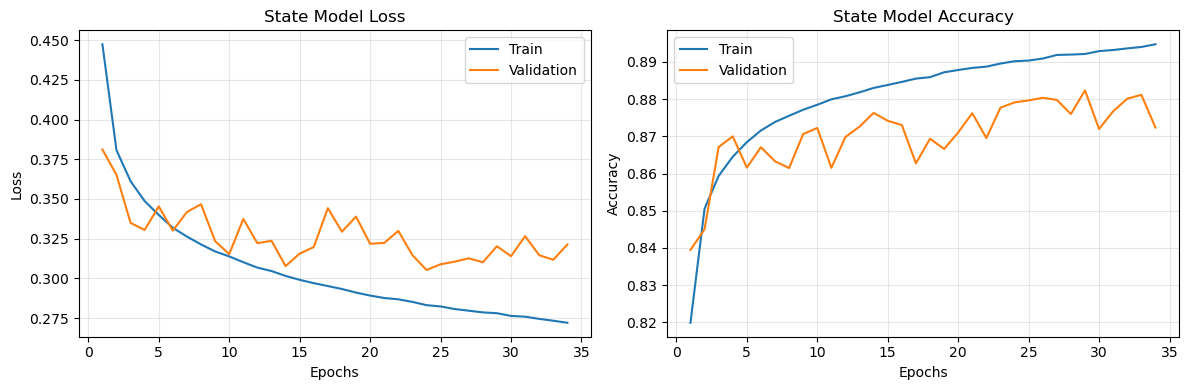

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
for i, metric in enumerate(['loss', 'accuracy']):
    for k, split in enumerate(['', 'val_']):
        data = state_history[f'{split}{metric}']
        axes[i].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
        axes[i].legend()
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel(metric.title())
        axes[i].set_title(f'State Model {metric.title()}')
        axes[i].grid(alpha=0.3)

plt.tight_layout()

#### 5.7 Freezing State Model & Training Object Model Only

In [26]:
state_model.trainable = False

In [27]:
# Scale the 3D tensors
X_train_scaled_flat = X_train_flat.copy()
X_train_scaled_flat[train_mask] = scaler.transform(X_train_flat[train_mask])
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)

X_val_scaled_flat = X_val_flat.copy()
X_val_scaled_flat[val_mask] = scaler.transform(X_val_flat[val_mask])
X_val_scaled = X_val_scaled_flat.reshape(X_val.shape)

X_test_flat = X_test.reshape(-1, N_FEATURES)
test_mask = ~(X_test_flat == PADDING_VALUE).all(axis=1)
X_test_scaled_flat = X_test_flat.copy()
X_test_scaled_flat[test_mask] = scaler.transform(X_test_flat[test_mask])
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)

In [28]:
# Repeat the train y's for the state model only
y_train_repeated = np.repeat(np.expand_dims(y_train, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)
y_val_repeated = np.repeat(np.expand_dims(y_val, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)

In [29]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.0001

# Input is a tensor of shape (BATCH_SIZE, MAX_STATE_COUNT, N_FEATURES
input = tf.keras.layers.Input(shape=(MAX_STATE_COUNT, N_FEATURES))

# Values of -999.0 are ignored
x = tf.keras.layers.Masking(mask_value=PADDING_VALUE)(input)

# Pass each state independently into the state_model, save output as 'state_output'
state_output = tf.keras.layers.TimeDistributed(state_model, name='state_output')(x)

# Feedforward neural network as the object_model
DROPOUT = 0.3
x = tf.keras.layers.Flatten()(state_output)
x = tf.keras.layers.Dense(512)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)

# Save the output of the object model as 'object_output'
object_output = tf.keras.layers.Dense(3, activation='softmax', name='object_output')(x)

object_model = tf.keras.Model(inputs=input, outputs=[state_output, object_output], name='object_model')
object_model.summary()

object_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss={'state_output': 'sparse_categorical_crossentropy', 'object_output': 'sparse_categorical_crossentropy'}, 
    loss_weights={'state_output': 1, 'object_output': 3}, # More emphasis on getting final object prediction right
    weighted_metrics={'state_output': 'accuracy', 'object_output': 'accuracy'},
)

# Create mask for the loss function so padded values don't contribute to the loss
mask = (X_train != PADDING_VALUE).any(axis=-1)
state_sample_weights = mask.astype(np.float32)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_object_output_loss', patience=10, restore_best_weights=True, verbose=1)

weights_path = 'models/object_model.weights.h5'

if os.path.exists(weights_path):
    print("Weights found. Loading existing weights...")
    object_model.load_weights(weights_path)
else:
    print("No saved weights found. Starting training...")
    object_model_history = object_model.fit(
        X_train_scaled,
        {'state_output': y_train_repeated, 'object_output': y_train},
        sample_weight={'state_output':state_sample_weights, 'object_output': np.ones(len(y_train))},
        validation_data=[X_val_scaled, {'state_output': y_val_repeated, 'object_output': y_val}],
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping]
    )
    object_history = object_model_history.history
    object_model.save_weights(weights_path)

Model: "object_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 49, 11)]          0         
                                                                 
 masking_1 (Masking)         (None, 49, 11)            0         
                                                                 
 state_output (TimeDistribu  (None, 49, 3)             172547    
 ted)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 147)               0         
                                                                 
 dense_8 (Dense)             (None, 512)               75776     
                                                                 
 layer_normalization_7 (Lay  (None, 512)               1024      
 erNormalization)                                     

Weights found. Loading existing weights...


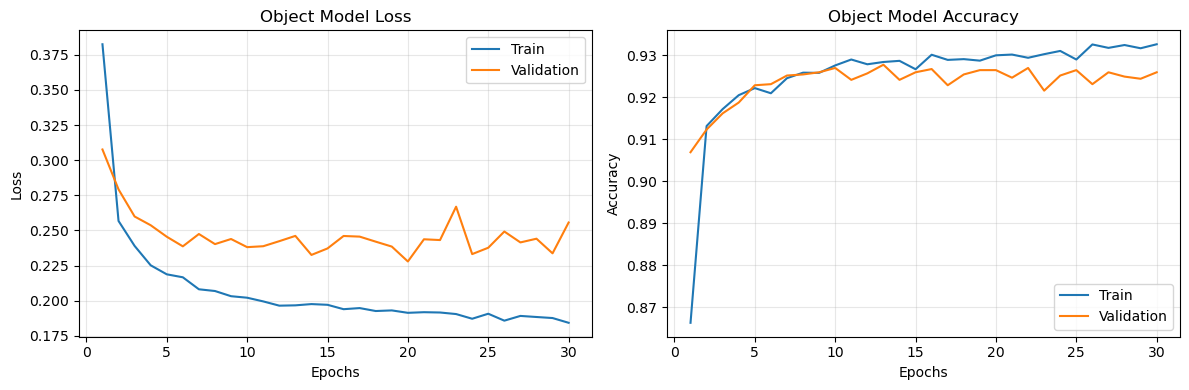

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
for i, metric in enumerate(['loss', 'accuracy']):
    for k, split in enumerate(['', 'val_']):
        data = object_history[f'{split}object_output_{metric}']
        axes[i].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
        axes[i].legend()
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel(metric.title())
        axes[i].set_title(f'Object Model {metric.title()}')
        axes[i].grid(alpha=0.3)

plt.tight_layout()

#### 5.8 Tuning Everything

In [31]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.00001

# Tune everything
state_model.trainable = True

object_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss={'state_output': 'sparse_categorical_crossentropy', 'object_output': 'sparse_categorical_crossentropy'}, 
    loss_weights={'state_output': 1, 'object_output': 3}, # More emphasis on getting final object prediction right
    weighted_metrics={'state_output': 'accuracy', 'object_output': 'accuracy'},
)

object_model.summary()

# Create mask for the loss function so padded values don't contribute to the loss
mask = (X_train != PADDING_VALUE).any(axis=-1)
state_sample_weights = mask.astype(np.float32)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_object_output_loss', patience=10, restore_best_weights=True, verbose=1)

weights_path = 'models/final_model.weights.h5'

if os.path.exists(weights_path):
    print("Weights found. Loading existing weights...")
    final_model.load_weights(weights_path)
else:
    print("No saved weights found. Starting training...")
    final_model_history = object_model.fit(
        X_train_scaled,
        {'state_output': y_train_repeated, 'object_output': y_train},
        sample_weight={'state_output':state_sample_weights, 'object_output': np.ones(len(y_train))},
        validation_data=[X_val_scaled, {'state_output': y_val_repeated, 'object_output': y_val}],
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping]
    )
    final_history = final_model_history.history
    object_model.save_weights(weights_path)

Model: "object_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 49, 11)]          0         
                                                                 
 masking_1 (Masking)         (None, 49, 11)            0         
                                                                 
 state_output (TimeDistribu  (None, 49, 3)             172547    
 ted)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 147)               0         
                                                                 
 dense_8 (Dense)             (None, 512)               75776     
                                                                 
 layer_normalization_7 (Lay  (None, 512)               1024      
 erNormalization)                                     

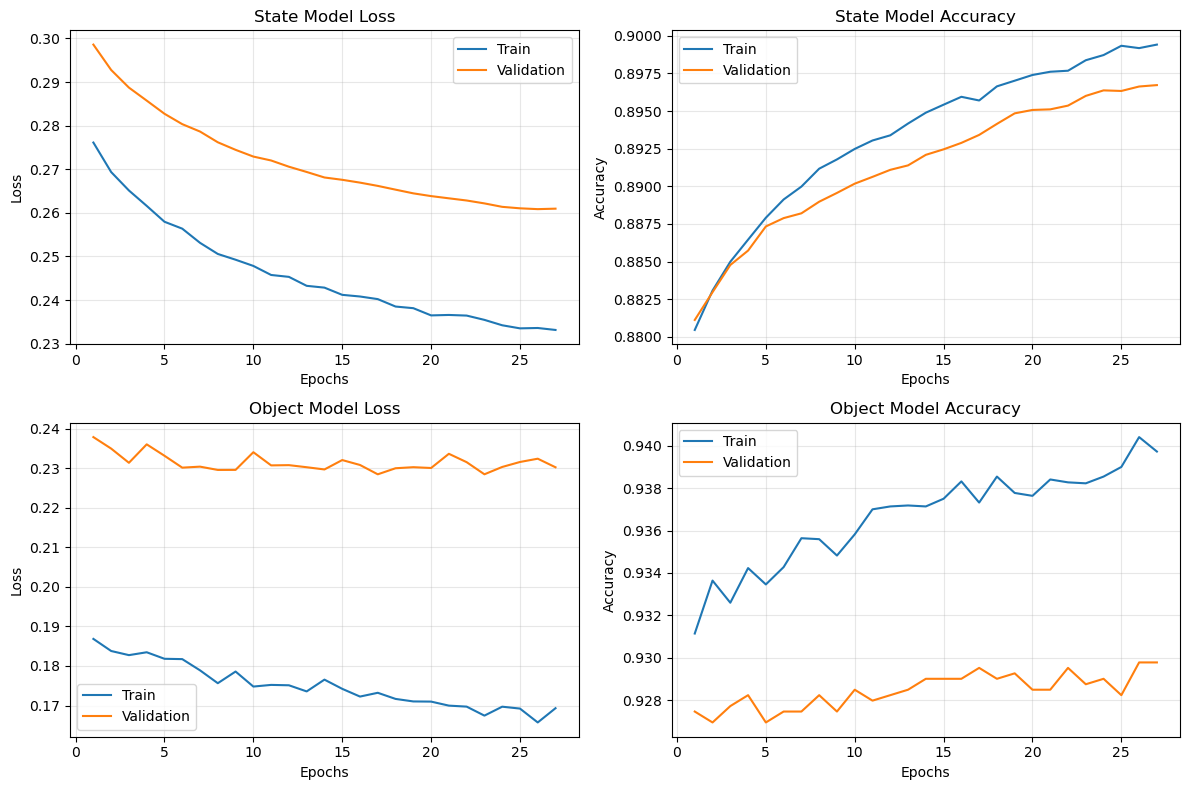

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
for i, level in enumerate(['state', 'object']):
    for j, metric in enumerate(['loss', 'accuracy']):
        for k, split in enumerate(['', 'val_']):
            data = final_history[f'{split}{level}_output_{metric}']
            axes[i][j].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
            axes[i][j].legend()
            axes[i][j].set_xlabel('Epochs')
            axes[i][j].set_ylabel(metric.title())
            axes[i][j].set_title(f'{level.title()} Model {metric.title()}')
            axes[i][j].grid(alpha=0.3)

plt.tight_layout()

---
### 6. Results <a class="anchor" id="6-results"></a>
---

**DIRECTIONS (DELETE LATER): Results: drawing reasonable conclusions & speculations, addressing strengths, limitations, and future works**

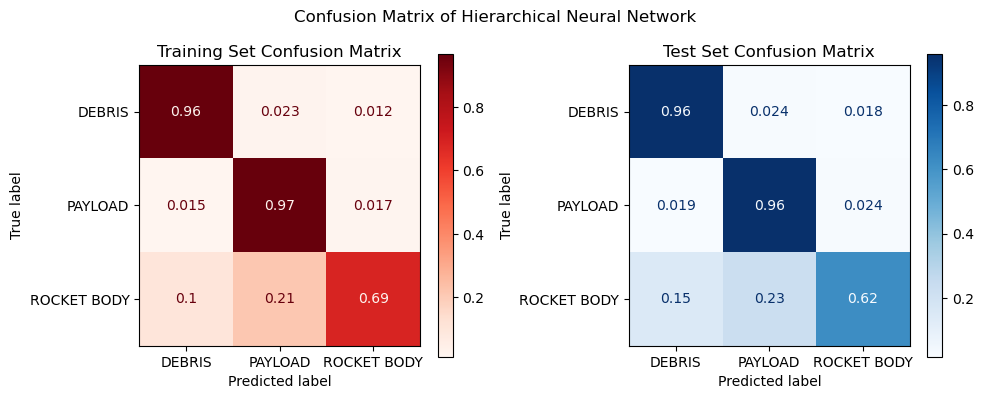

In [33]:
y_train_pred = np.argmax(object_model.predict(X_train_scaled, verbose=0)[1], axis=-1)
y_test_pred = np.argmax(object_model.predict(X_test_scaled, verbose=0)[1], axis=-1)
viz.plot_side_my_side_confusion("Confusion Matrix of Hierarchical Neural Network", y_train, y_train_pred, "Training Set Confusion Matrix", y_test, y_test_pred, "Test Set Confusion Matrix", label_encoder)

In [34]:
train_loss, train_state_loss, train_object_loss, train_state_acc, train_object_acc = object_model.evaluate(X_train_scaled, [y_train_repeated, y_train])
y_test_repeated = np.repeat(np.expand_dims(y_test, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)
test_loss, test_state_loss, test_object_loss, test_state_acc, test_object_acc = object_model.evaluate(X_test_scaled, [y_test_repeated, y_test])

143/143 [==============================] - 1s 4ms/step - loss: 0.8962 - state_output_loss: 0.2689 - object_output_loss: 0.2091 - state_output_accuracy: 0.8935 - object_output_accuracy: 0.9316


In [35]:
print('===== TRAIN =====')
print(f'Object Accuracy: {train_object_acc:.2%}')
print(f'Object Loss: {train_object_loss:.5f}')
print(f'State Accuracy: {train_state_acc:.2%}')
print(f'State Loss: {train_state_loss:.5f}')
print(f'Aggregate Loss: {train_loss:.5f}')
print('\n===== TEST =====')
print(f'Object Accuracy: {test_object_acc:.2%}')
print(f'Object Loss: {test_object_loss:.5f}')
print(f'State Accuracy: {test_state_acc:.2%}')
print(f'State Loss: {test_state_loss:.5f}')
print(f'Aggregate Loss: {test_loss:.5f}')

===== TRAIN =====
Object Accuracy: 94.50%
Object Loss: 0.15396
State Accuracy: 90.66%
State Loss: 0.20976
Aggregate Loss: 0.67164

===== TEST =====
Object Accuracy: 93.16%
Object Loss: 0.20909
State Accuracy: 89.35%
State Loss: 0.26891
Aggregate Loss: 0.89619


---
### References <a class="anchor" id="refs"></a>
---

**DIRECTIONS (DELETE LATER): Cite every outside source**